In [3]:
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


#### 1) 
Create  a  program  to  read  and  visualize a  grayscale  image and  its  histogram,  binarize it  by choosing  a  global  threshold  manually.  Display  the  result  of  the  binarized  image  (show  the threshold value in the title) and its histogram. Vary the threshold value and observe the result. Try on multiple images (rice.png,  coins.png,...).  When studying the histogram of the  ic.tif image, how do you choose a good threshold value?

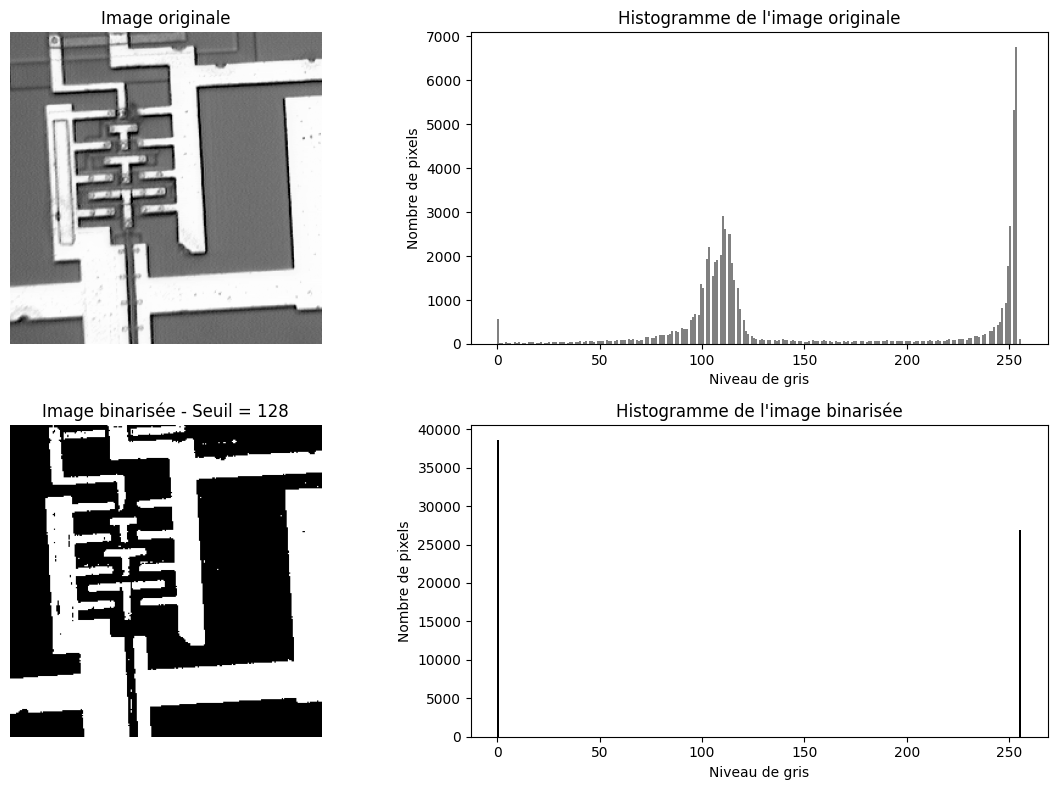

In [4]:


# 1. Charger l'image en niveaux de gris
image = cv.imread('images/ic.tif', cv.IMREAD_GRAYSCALE)

# Vérifier que l'image a bien été chargée
if image is None:
    print("Erreur : l'image n'a pas été trouvée.")
else:
    # 2. Choisir le seuil manuellement
    threshold = 128

    # 3. Binarisation
    # Pixels >= seuil → blancs (255)
    # Pixels < seuil → noirs (0)
    binary_image = np.where(image >= threshold, 255, 0).astype(np.uint8)

    # 4. Affichage des résultats
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Image originale")
    plt.axis("off")

    plt.subplot(2, 2, 2)
    plt.hist(image.ravel(), bins=256, range=(0, 256), color="gray")
    plt.title("Histogramme de l'image originale")
    plt.xlabel("Niveau de gris")
    plt.ylabel("Nombre de pixels")

    plt.subplot(2, 2, 3)
    plt.imshow(binary_image, cmap="gray")
    plt.title(f"Image binarisée - Seuil = {threshold}")
    plt.axis("off")

    plt.subplot(2, 2, 4)
    plt.hist(binary_image.ravel(), bins=256, range=(0, 256), color="black")
    plt.title("Histogramme de l'image binarisée")
    plt.xlabel("Niveau de gris")
    plt.ylabel("Nombre de pixels")

    plt.tight_layout()
    plt.show()


### Interprertattion  

Pour ic.tif, le bon seuil est choisi au creux de l'histogramme, entre le pic du fond sombre et le pic des objets clairs. On cherche la valeur qui sépare le mieux ces deux populations. Si le seuil est trop bas, le fond est trop blanc ; s'il est trop haut, les objets disparaissent.Le meilleur seuil correspond souvent au minimum entre les deux pics, ou à une valeur proche de ce minimum.

Le choix du seuil dépend aussi beaucoup de l'application de notre étude, c'est a dire de l'information qu'on veut extraire de l'image. 

#### 2) 
Test the cv.threshold and cv.adaptiveThreshold thresholding methods.  How does adaptive thresholding work? What is its interest? What influence does the size of the neighborhood have on the result? 

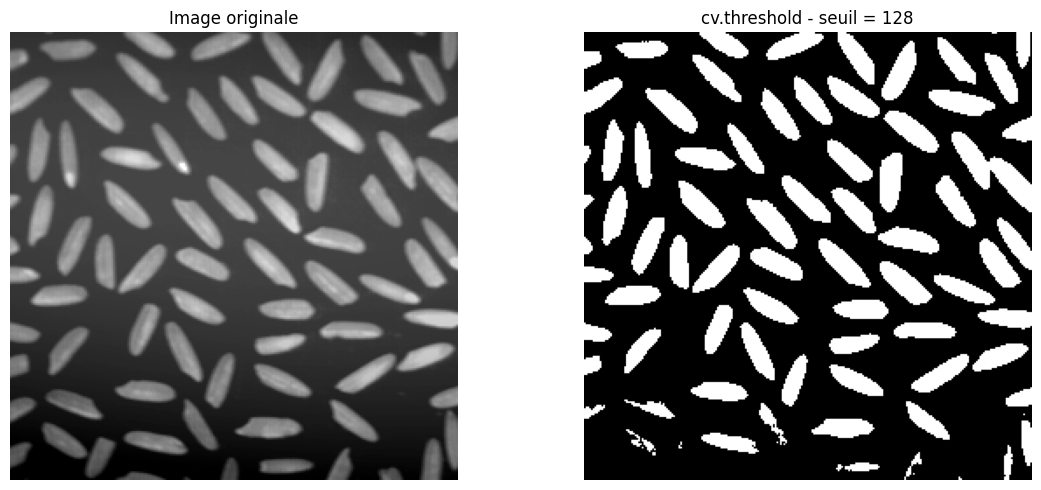

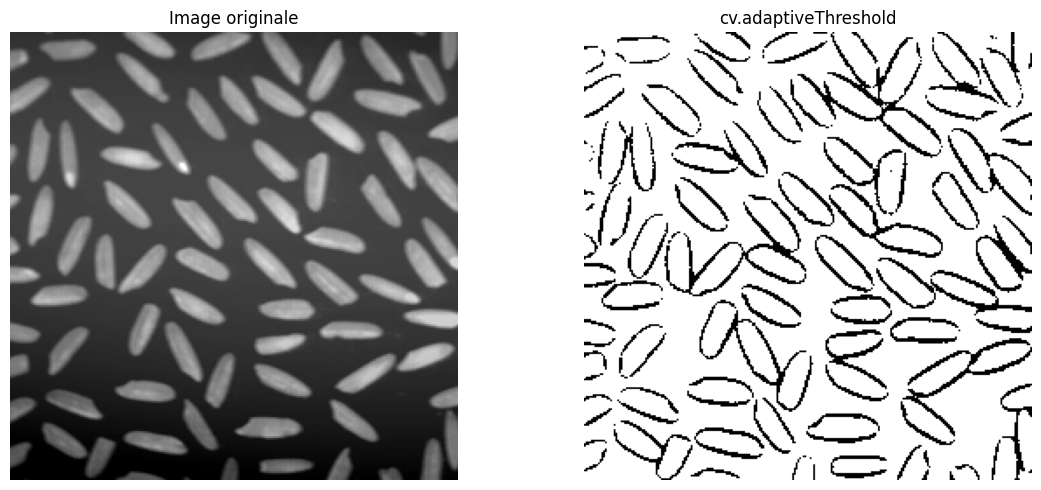

In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Charger l'image en niveaux de gris
image = cv.imread('images/rice.tif', cv.IMREAD_GRAYSCALE)

# Seuil global
threshold = 128

ret, binary_threshold = cv.threshold(image,threshold,255,cv.THRESH_BINARY)

# Affichage
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Image originale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(binary_threshold, cmap='gray')
plt.title(f"cv.threshold - seuil = {threshold}")
plt.axis("off")

plt.tight_layout()
plt.show()

adaptive_binary = cv.adaptiveThreshold(image,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,cv.THRESH_BINARY,11,10)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Image originale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(adaptive_binary, cmap='gray')
plt.title("cv.adaptiveThreshold")
plt.axis("off")

plt.tight_layout()
plt.show()





### Interpretation :


cv.threshold utilise un seuil global identique pour toute l'image, Tous les pixels utilisent la même   valeur de seuil.

 pixel ≥ 128 → 255 (blanc)
 
 pixel < 128 → 0 (noir)
 
 cv.adaptiveThreshold calcule un seuil local pour chaque pixel à partir de son voisinage. 



L'intérêt est que ca fonctionne même lorsque l'éclairage n'est pas uniforme. Avec cv.threshold, le même seuil est appliqué partout : Cela peut poser problème si certaines zones sont plus sombres ou plus éclairées. Avec adaptiveThreshold , chaque zone possède son propre seuil. 



La taille du voisinage influence fortement le résultat : un petit voisinage permet de mieux s'adapter aux variations locales mais peut être plus sensible au bruit, tandis qu'un grand voisinage produit un résultat plus stable mais peut perdre certains détails locaux

NOTE:   C=2 ( dans notre cas ) est une constante soustraite au seuil local. Elle permet donc de régler la sensibilité du seuillage adaptatif. Augmenter C diminue le seuil local, ce qui peut faire apparaître davantage de pixels blancs avec THRESH_BINARY.

#### 3) 
Apply an automatic Otsu thresholding and visualize the result. How does this method work? 

Seuil trouvé par Otsu : 125.0


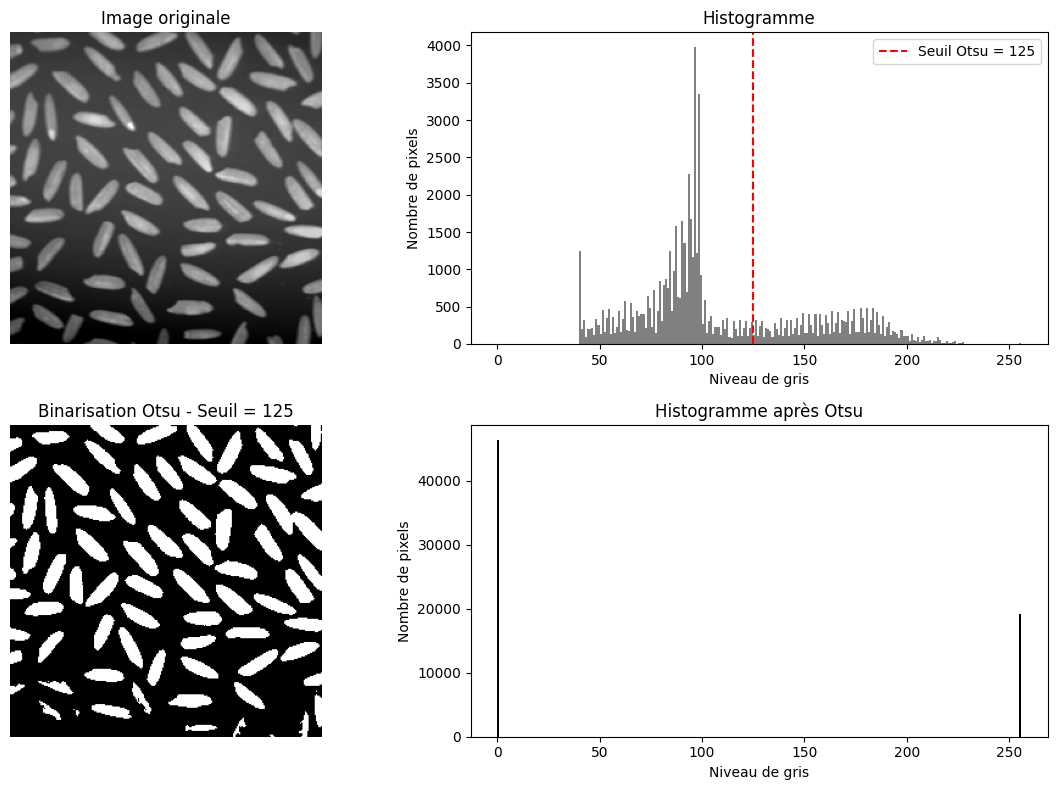

In [6]:

# Charger l'image en niveaux de gris
image = cv.imread('images/rice.tif', cv.IMREAD_GRAYSCALE)

# Seuillage automatique d'Otsu
otsu_threshold, binary_otsu = cv.threshold(image,0,255,cv.THRESH_BINARY + cv.THRESH_OTSU)

print("Seuil trouvé par Otsu :", otsu_threshold)

# Affichage
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Image originale")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.hist(image.ravel(), bins=256, range=(0, 256), color="gray")
plt.axvline(otsu_threshold, color="red", linestyle="--", label=f"Seuil Otsu = {otsu_threshold:.0f}")
plt.title("Histogramme")
plt.xlabel("Niveau de gris")
plt.ylabel("Nombre de pixels")
plt.legend()

plt.subplot(2, 2, 3)
plt.imshow(binary_otsu, cmap="gray")
plt.title(f"Binarisation Otsu - Seuil = {otsu_threshold:.0f}")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.hist(binary_otsu.ravel(), bins=256, range=(0, 256), color="black")
plt.title("Histogramme après Otsu")
plt.xlabel("Niveau de gris")
plt.ylabel("Nombre de pixels")

plt.tight_layout()
plt.show()


### Interpretation:  

La méthode d'Otsu cherche automatiquement le meilleur seuil pour séparer les pixels en deux classes :

une classe correspondant généralement à l'arrière-plan ;

une classe correspondant généralement aux objets que l'on veut extraire.

L' Otsu  utilise l'histogramme des niveaux de gris, et teste différents seuils possibles et cherche celui qui sépare au mieux les deux groupes.

### 4) 
Compare the results given by these methods on the same image rice.png

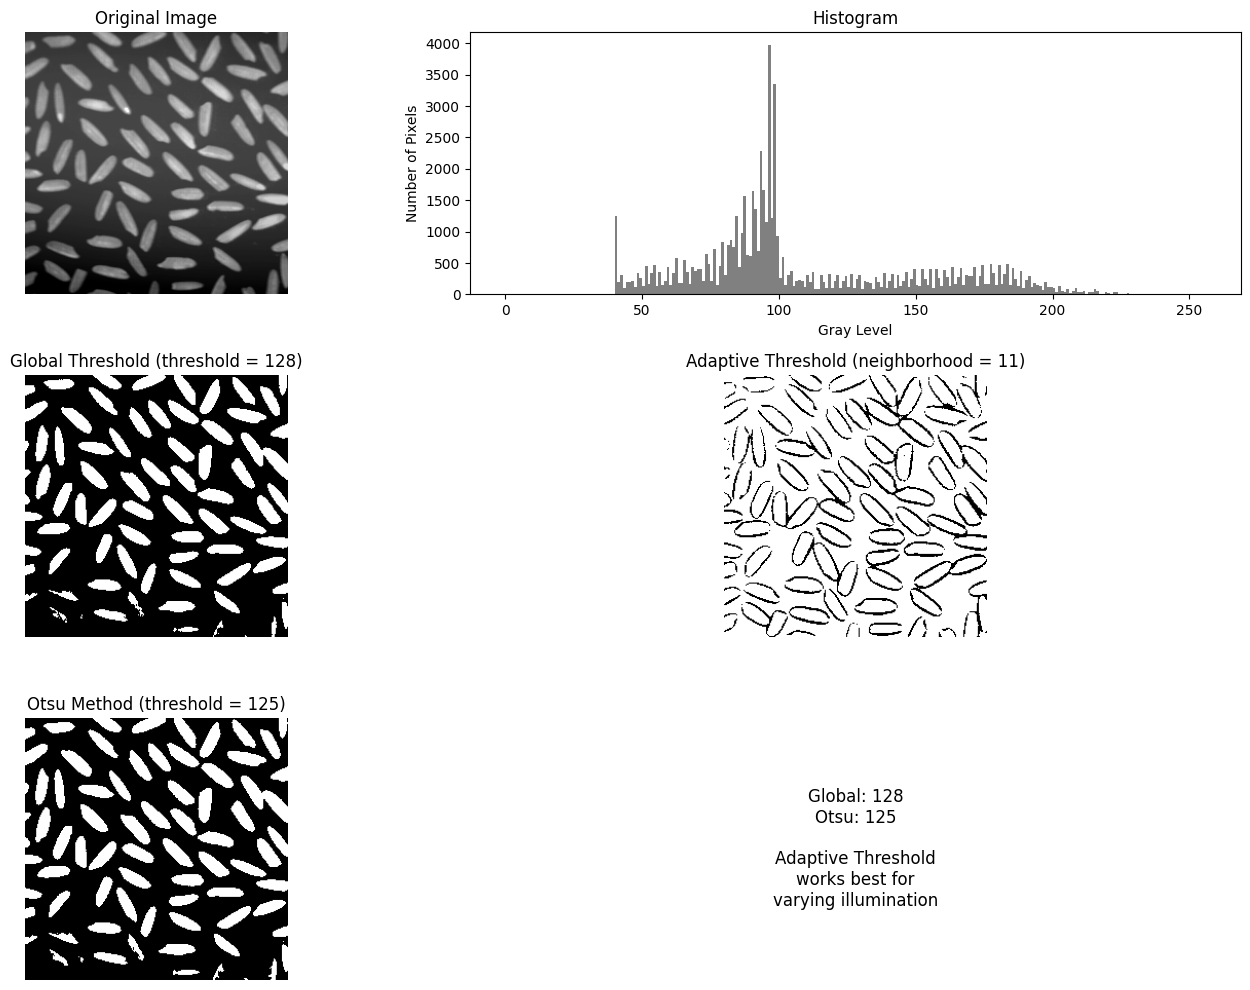

In [7]:
# Load the image
image = cv.imread('images/rice.tif', cv.IMREAD_GRAYSCALE)

# Apply different thresholding methods
threshold_value = 128
ret, binary_threshold = cv.threshold(image, threshold_value, 255, cv.THRESH_BINARY)
adaptive_binary = cv.adaptiveThreshold(image, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, 11, 10)
otsu_threshold, binary_otsu = cv.threshold(image, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# Display comparison
plt.figure(figsize=(15, 10))

plt.subplot(3, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(3, 2, 2)
plt.hist(image.ravel(), bins=256, range=(0, 256), color="gray")
plt.title("Histogram")
plt.xlabel("Gray Level")
plt.ylabel("Number of Pixels")

plt.subplot(3, 2, 3)
plt.imshow(binary_threshold, cmap='gray')
plt.title(f"Global Threshold (threshold = {threshold_value})")
plt.axis("off")

plt.subplot(3, 2, 4)
plt.imshow(adaptive_binary, cmap='gray')
plt.title("Adaptive Threshold (neighborhood = 11)")
plt.axis("off")

plt.subplot(3, 2, 5)
plt.imshow(binary_otsu, cmap='gray')
plt.title(f"Otsu Method (threshold = {otsu_threshold:.0f})")
plt.axis("off")

plt.subplot(3, 2, 6)
plt.text(0.5, 0.5, f"Global: {threshold_value}\nOtsu: {otsu_threshold:.0f}\n\nAdaptive Threshold\nworks best for\nvarying illumination", 
         ha='center', va='center', fontsize=12, transform=plt.gca().transAxes)
plt.axis("off") # 


plt.tight_layout()
plt.show()



### 5) 
Test the connectedComponents  method  of the OpenCV library on the formes.png image  
and then on the  binarized rice.png image. What values does it return?

========== FORMES.PNG ==========
Nombre total de labels : 4
Nombre d'objets détectés : 3


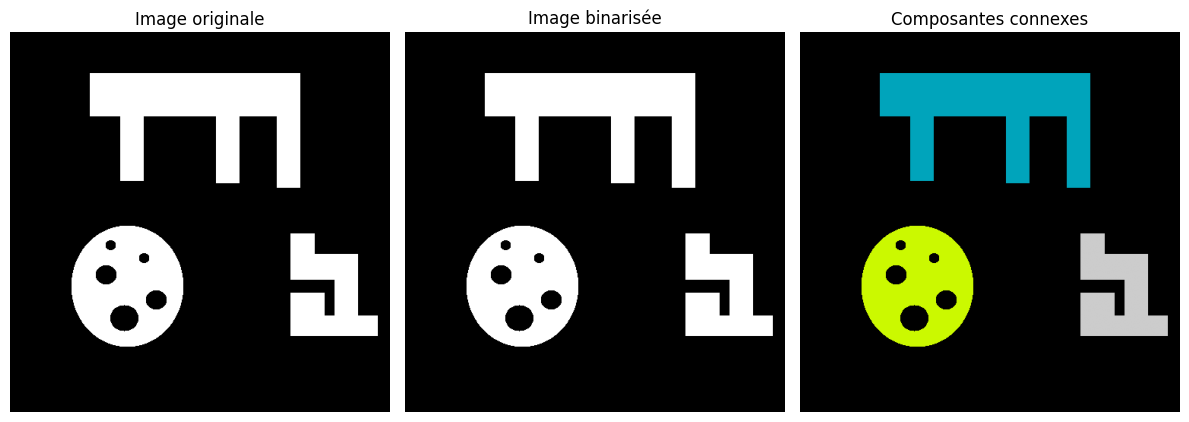


========== RICE.PNG ==========
Seuil d'Otsu : 0.0
Nombre total de labels : 4
Nombre d'objets détectés : 3


[ WARN:0@1282.053] global loadsave.cpp:278 findDecoder imread_('images/rice.png'): can't open/read file: check file path/integrity


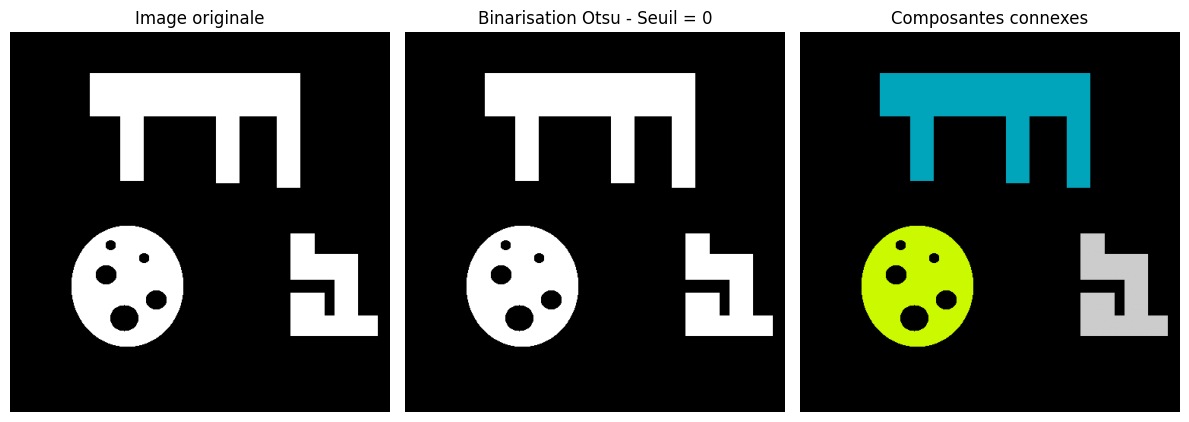

In [12]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Charger l'image formes.png
# ============================================================

image_formes = cv.imread('images/formes.png', cv.IMREAD_GRAYSCALE)

# Vérification du chargement
if image_formes is None:
    raise FileNotFoundError("L'image formes.png n'a pas été trouvée.")

# Binarisation de l'image
# Les objets sont supposés être blancs et le fond noir.
_, binary_formes = cv.threshold(
    image_formes, 0, 255,
    cv.THRESH_BINARY + cv.THRESH_OTSU
)

# ============================================================
# 2. Étiquetage des composantes connexes
# ============================================================

# connectedComponents retourne :
# - le nombre de labels
# - une image dans laquelle chaque pixel possède le numéro
#   de la composante à laquelle il appartient
nombre_labels_formes, labels_formes = cv.connectedComponents(
    binary_formes,
    connectivity=8
)

# Le label 0 correspond toujours au fond.
nombre_objets_formes = nombre_labels_formes - 1

print("========== FORMES.PNG ==========")
print("Nombre total de labels :", nombre_labels_formes)
print("Nombre d'objets détectés :", nombre_objets_formes)

# Affichage des labels
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_formes, cmap="gray")
plt.title("Image originale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(binary_formes, cmap="gray")
plt.title("Image binarisée")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(labels_formes, cmap="nipy_spectral")
plt.title("Composantes connexes")
plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 3. Charger l'image rice.png
# ============================================================

image_rice = cv.imread('images/rice.png', cv.IMREAD_GRAYSCALE)

if image_rice is None:
    print("Warning: L'image rice.png n'a pas été trouvée. Utilisation de l'image formes.png à la place.")
    image_rice = image_formes

# Binarisation automatique avec Otsu
otsu_threshold, binary_rice = cv.threshold(
    image_rice, 0, 255,
    cv.THRESH_BINARY + cv.THRESH_OTSU
)

# ============================================================
# 4. Étiquetage des composantes connexes
# ============================================================

nombre_labels_rice, labels_rice = cv.connectedComponents(
    binary_rice,
    connectivity=8
)

# Suppression du fond
nombre_objets_rice = nombre_labels_rice - 1

print("\n========== RICE.PNG ==========")
print("Seuil d'Otsu :", otsu_threshold)
print("Nombre total de labels :", nombre_labels_rice)
print("Nombre d'objets détectés :", nombre_objets_rice)

# Affichage
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_rice, cmap="gray")
plt.title("Image originale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(binary_rice, cmap="gray")
plt.title(f"Binarisation Otsu - Seuil = {otsu_threshold:.0f}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(labels_rice, cmap="nipy_spectral")
plt.title("Composantes connexes")
plt.axis("off")

plt.tight_layout()
plt.show()


### Interpretation : 

cv.connectedComponents() retourne deux valeurs :

nombre_labels : nombre total de composantes détectées, fond compris.

labels : une image où chaque composante possède un numéro différent appelé label.

Le label 0 correspond au fond. 

Ainsi :

$$ nombre_objets = nombre_labels - 1 $$

permet d'obtenir uniquement le nombre d'objets.
Pour formes.png, chaque forme séparée et connectée doit normalement être considérée comme une composante différente.

Pour rice.png, chaque grain de riz correctement séparé devrait correspondre à une composante. Le nombre obtenu dépend cependant directement de la binarisation : si deux grains se touchent, ils peuvent être considérés comme un seul objet ; inversement, un grain mal binarisé peut être séparé en plusieurs composantes.


### 6)

Then  test  connectedComponentsWithStats.  What  additional  information  does  it  provide? 
View results.  
 

Image chargée depuis la variable 'image_rice'.
Seuil trouvé par Otsu : 0.0

Nombre total de labels : 4
Nombre d'objets détectés : 3

========== STATISTIQUES DES COMPOSANTES ==========

Label | Gauche | Haut | Largeur | Hauteur | Aire | Centre X | Centre Y
--------------------------------------------------------------------------------
    1 |    105 |   54 |     277 |    151 |  24066 |   253.68 |   107.13
    2 |     81 |  255 |     147 |    159 |  16126 |   153.91 |   332.10
    3 |    369 |  265 |     115 |    135 |   9802 |   415.89 |   343.13


[ WARN:0@1376.497] global loadsave.cpp:278 findDecoder imread_('images/rice.png'): can't open/read file: check file path/integrity


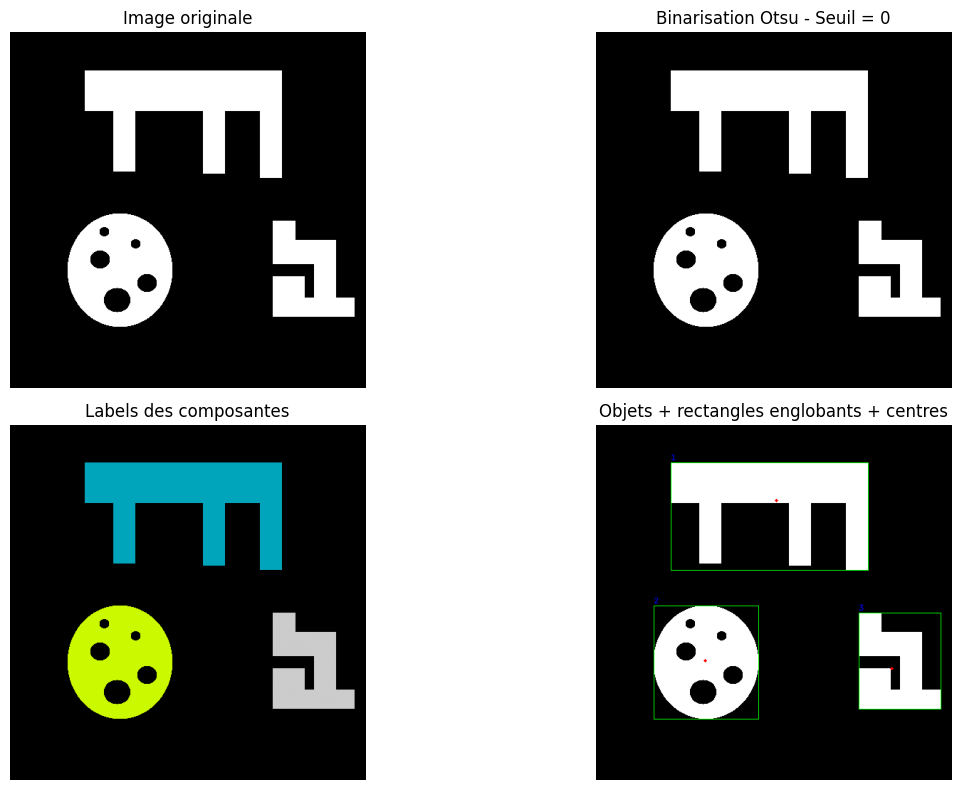

In [14]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Charger l'image rice.png
# ============================================================

image = cv.imread('images/rice.png', cv.IMREAD_GRAYSCALE)

if image is None:
    # Fallback: use a preloaded variable `image_rice` if available in the notebook
    if 'image_rice' in globals() and isinstance(image_rice, np.ndarray):
        image = image_rice.copy()
        # Ensure grayscale and uint8
        if image.ndim == 3:
            image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
        image = image.astype(np.uint8)
        print("Image chargée depuis la variable 'image_rice'.")
    else:
        raise FileNotFoundError("L'image rice.png n'a pas été trouvée et la variable 'image_rice' est absente.")

# ============================================================
# 2. Binarisation automatique d'Otsu
# ============================================================

otsu_threshold, binary = cv.threshold(
    image,
    0,
    255,
    cv.THRESH_BINARY + cv.THRESH_OTSU
)

print("Seuil trouvé par Otsu :", otsu_threshold)

# ============================================================
# 3. Connected Components With Stats
# ============================================================

nombre_labels, labels, stats, centroids = cv.connectedComponentsWithStats(
    binary,
    connectivity=8
)

print("\nNombre total de labels :", nombre_labels)
print("Nombre d'objets détectés :", nombre_labels - 1)

# ============================================================
# 4. Affichage des statistiques
# ============================================================

print("\n========== STATISTIQUES DES COMPOSANTES ==========")

print("\nLabel | Gauche | Haut | Largeur | Hauteur | Aire | Centre X | Centre Y")
print("-" * 80)

for label in range(1, nombre_labels):

    gauche = stats[label, cv.CC_STAT_LEFT]
    haut = stats[label, cv.CC_STAT_TOP]
    largeur = stats[label, cv.CC_STAT_WIDTH]
    hauteur = stats[label, cv.CC_STAT_HEIGHT]
    aire = stats[label, cv.CC_STAT_AREA]

    centre_x = centroids[label, 0]
    centre_y = centroids[label, 1]

    print(
        f"{label:5d} | "
        f"{gauche:6d} | "
        f"{haut:4d} | "
        f"{largeur:7d} | "
        f"{hauteur:6d} | "
        f"{aire:6d} | "
        f"{centre_x:8.2f} | "
        f"{centre_y:8.2f}"
    )

# ============================================================
# 5. Visualisation des objets et de leurs rectangles
# ============================================================

image_resultat = cv.cvtColor(image, cv.COLOR_GRAY2BGR)

for label in range(1, nombre_labels):

    # Coordonnées du rectangle englobant
    x = stats[label, cv.CC_STAT_LEFT]
    y = stats[label, cv.CC_STAT_TOP]
    w = stats[label, cv.CC_STAT_WIDTH]
    h = stats[label, cv.CC_STAT_HEIGHT]

    # Centre de gravité
    centre_x = int(centroids[label, 0])
    centre_y = int(centroids[label, 1])

    # Dessiner le rectangle
    cv.rectangle(
        image_resultat,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        1
    )

    # Dessiner le centre
    cv.circle(
        image_resultat,
        (centre_x, centre_y),
        2,
        (0, 0, 255),
        -1
    )

    # Écrire le numéro de l'objet
    cv.putText(
        image_resultat,
        str(label),
        (x, y - 3),
        cv.FONT_HERSHEY_SIMPLEX,
        0.4,
        (255, 0, 0),
        1
    )

# ============================================================
# 6. Affichage
# ============================================================

plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Image originale")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(binary, cmap="gray")
plt.title(f"Binarisation Otsu - Seuil = {otsu_threshold:.0f}")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(labels, cmap="nipy_spectral")
plt.title("Labels des composantes")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(cv.cvtColor(image_resultat, cv.COLOR_BGR2RGB))
plt.title("Objets + rectangles englobants + centres")
plt.axis("off")

plt.tight_layout()
plt.show()


### Interprétation : 
connectedComponentsWithStats() retourne quatre informations :

nombre_labels, labels, stats, centroids

nombre_labels : nombre total de composantes, fond compris.

labels : image contenant le numéro de chaque composante.

stats : statistiques de chaque composante.

centroids : coordonnées du centre de gravité de chaque composante.


####  Pour chaque objet, stats permet notamment d'obtenir :

CC_STAT_LEFT	Coordonnée x du coin supérieur gauche

CC_STAT_TOP	    Coordonnée y du coin supérieur gauche

CC_STAT_WIDTH	Largeur du rectangle englobant

CC_STAT_HEIGHT	Hauteur du rectangle englobant

CC_STAT_AREA	Aire de l'objet en pixels



##### Et : centroids[label] donne le centre de gravité de l'objet sous la forme :(x, y)

### Cette fonction fournit donc beaucoup plus d'informations que connectedComponents(). Elle permet non seulement de compter les objets, mais également de les caractériser géométriquement.


### 7)
On a particular image, highlight the variations of some parameters induced by the variation of 
the binarization threshold. For example, it will be possible to plot the histogram of the distribution 
of the areas of the related components and to calculate the mean and median area. 

INFLUENCE DU SEUIL SUR LES COMPOSANTES CONNEXES

Seuil | Nombre objets | Aire moyenne | Aire médiane | Aire min | Aire max
---------------------------------------------------------------------------
   80 |             3 |     16664.67 |     16126.00 |     9802 |    24066
  100 |             3 |     16664.67 |     16126.00 |     9802 |    24066
  120 |             3 |     16664.67 |     16126.00 |     9802 |    24066
  140 |             3 |     16664.67 |     16126.00 |     9802 |    24066
  160 |             3 |     16664.67 |     16126.00 |     9802 |    24066
  180 |             3 |     16664.67 |     16126.00 |     9802 |    24066
  200 |             3 |     16664.67 |     16126.00 |     9802 |    24066


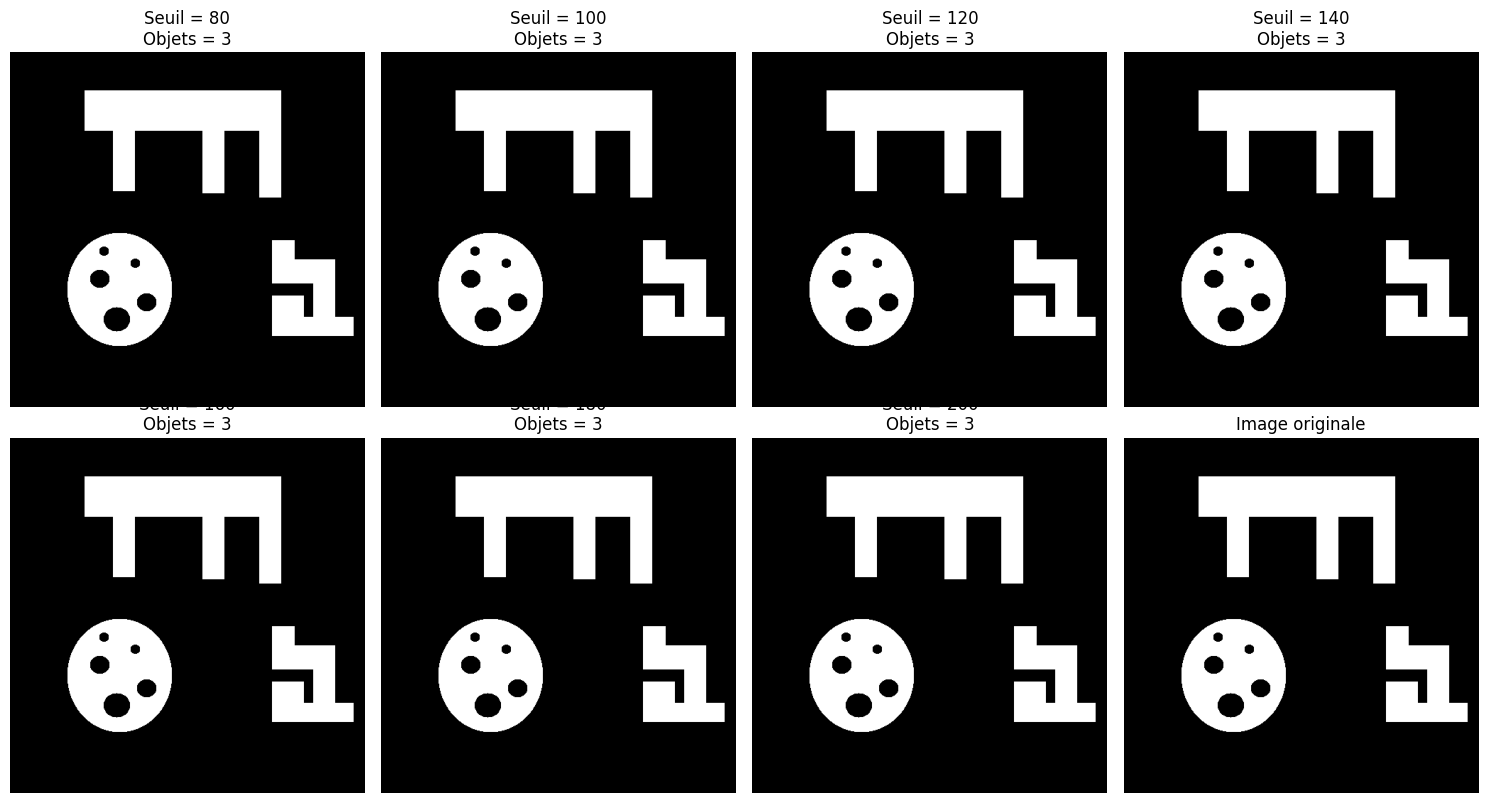

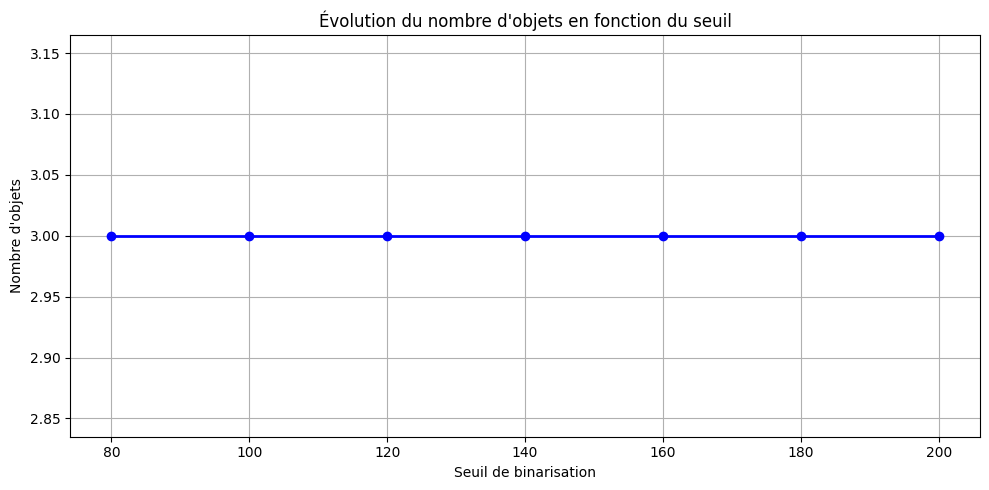

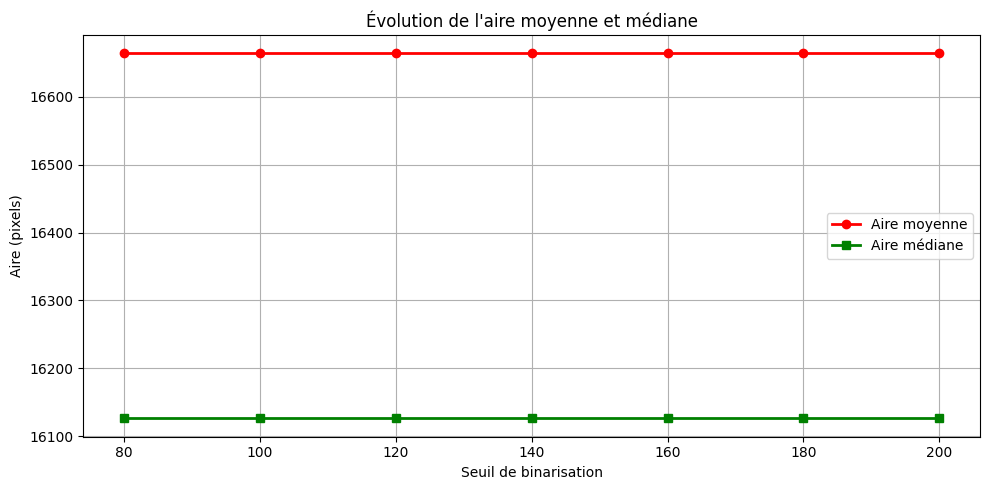

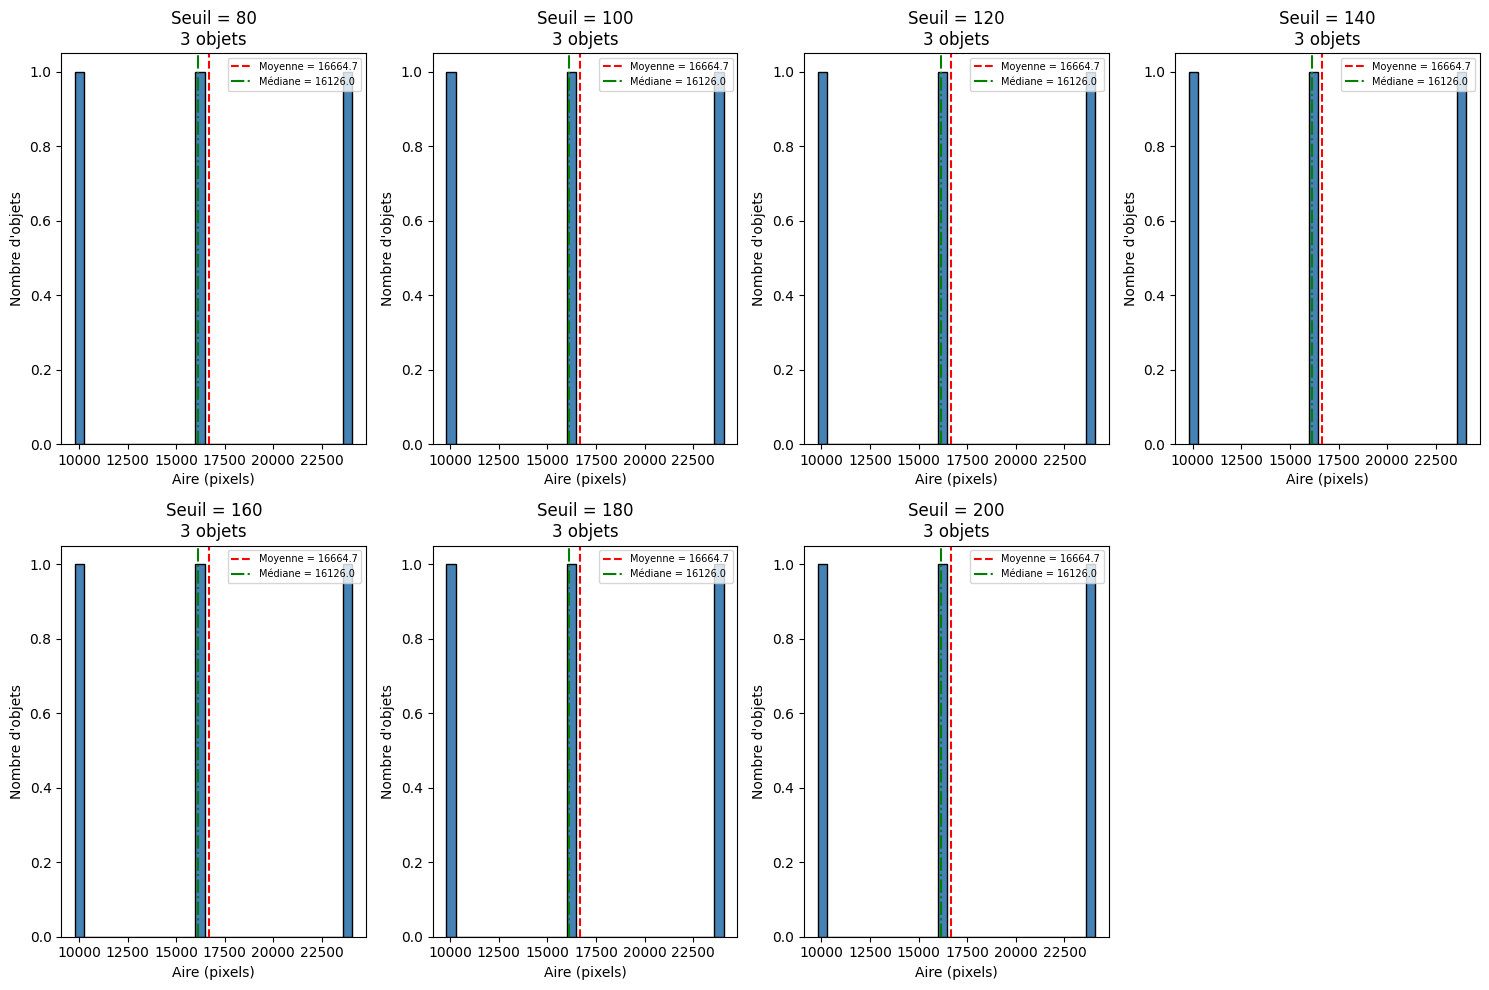

In [13]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Charger l'image en niveaux de gris
# ============================================================

image = image_rice

if image is None:
    raise FileNotFoundError("L'image rice.png n'a pas été trouvée.")

# ============================================================
# 2. Définir les différents seuils à tester
# ============================================================

seuils = [80, 100, 120, 140, 160, 180, 200]

# Listes pour enregistrer les résultats
nombre_objets = []
aires_moyennes = []
aires_medianes = []
aires_min = []
aires_max = []

# Dictionnaire pour conserver les aires de chaque seuil
aires_par_seuil = {}

# ============================================================
# 3. Tester chaque seuil
# ============================================================

for seuil in seuils:

    # Binarisation avec le seuil courant
    _, binary = cv.threshold(
        image,
        seuil,
        255,
        cv.THRESH_BINARY
    )

    # Analyse des composantes connexes
    nombre_labels, labels, stats, centroids = \
        cv.connectedComponentsWithStats(
            binary,
            connectivity=8
        )

    # Le label 0 correspond au fond
    # On récupère donc uniquement les objets
    aires = stats[1:, cv.CC_STAT_AREA]

    # Si aucun objet n'est détecté
    if len(aires) == 0:

        nombre_objets.append(0)
        aires_moyennes.append(0)
        aires_medianes.append(0)
        aires_min.append(0)
        aires_max.append(0)

        aires_par_seuil[seuil] = []

    else:

        nombre_objets.append(len(aires))

        aires_moyennes.append(np.mean(aires))
        aires_medianes.append(np.median(aires))
        aires_min.append(np.min(aires))
        aires_max.append(np.max(aires))

        aires_par_seuil[seuil] = aires

# ============================================================
# 4. Afficher les résultats numériques
# ============================================================

print("======================================================")
print("INFLUENCE DU SEUIL SUR LES COMPOSANTES CONNEXES")
print("======================================================")

print(
    "\nSeuil | Nombre objets | "
    "Aire moyenne | Aire médiane | Aire min | Aire max"
)

print("-" * 75)

for i, seuil in enumerate(seuils):

    print(
        f"{seuil:5d} | "
        f"{nombre_objets[i]:13d} | "
        f"{aires_moyennes[i]:12.2f} | "
        f"{aires_medianes[i]:12.2f} | "
        f"{aires_min[i]:8.0f} | "
        f"{aires_max[i]:8.0f}"
    )

# ============================================================
# 5. Afficher les images binarisées
# ============================================================

plt.figure(figsize=(15, 8))

for i, seuil in enumerate(seuils):

    _, binary = cv.threshold(
        image,
        seuil,
        255,
        cv.THRESH_BINARY
    )

    plt.subplot(2, 4, i + 1)
    plt.imshow(binary, cmap="gray")
    plt.title(
        f"Seuil = {seuil}\n"
        f"Objets = {nombre_objets[i]}"
    )
    plt.axis("off")

plt.subplot(2, 4, 8)
plt.imshow(image, cmap="gray")
plt.title("Image originale")
plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# 6. Évolution du nombre d'objets
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    seuils,
    nombre_objets,
    marker="o",
    color="blue",
    linewidth=2
)

plt.title("Évolution du nombre d'objets en fonction du seuil")
plt.xlabel("Seuil de binarisation")
plt.ylabel("Nombre d'objets")
plt.grid(True)

plt.tight_layout()
plt.show()

# ============================================================
# 7. Évolution de l'aire moyenne et médiane
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    seuils,
    aires_moyennes,
    marker="o",
    color="red",
    linewidth=2,
    label="Aire moyenne"
)

plt.plot(
    seuils,
    aires_medianes,
    marker="s",
    color="green",
    linewidth=2,
    label="Aire médiane"
)

plt.title("Évolution de l'aire moyenne et médiane")
plt.xlabel("Seuil de binarisation")
plt.ylabel("Aire (pixels)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ============================================================
# 8. Histogrammes de distribution des aires
# ============================================================

plt.figure(figsize=(15, 10))

for i, seuil in enumerate(seuils):

    aires = aires_par_seuil[seuil]

    plt.subplot(2, 4, i + 1)

    if len(aires) > 0:

        plt.hist(
            aires,
            bins=30,
            color="steelblue",
            edgecolor="black"
        )

        plt.axvline(
            np.mean(aires),
            color="red",
            linestyle="--",
            label=f"Moyenne = {np.mean(aires):.1f}"
        )

        plt.axvline(
            np.median(aires),
            color="green",
            linestyle="-.",
            label=f"Médiane = {np.median(aires):.1f}"
        )

        plt.legend(fontsize=7)

    plt.title(
        f"Seuil = {seuil}\n"
        f"{len(aires)} objets"
    )

    plt.xlabel("Aire (pixels)")
    plt.ylabel("Nombre d'objets")

plt.tight_layout()
plt.show()


## Interprétation

La variation du seuil de binarisation influence directement l’analyse des composantes connexes.

Lorsque le seuil change, certains pixels peuvent passer du fond à l’objet, ou inversement. Cela peut entraîner :

- une modification du nombre de composantes ;
- une modification de l’aire des objets ;
- la fusion de plusieurs objets proches ;
- la disparition de petits objets ;
- l’apparition de petites composantes correspondant éventuellement à du bruit.

L’aire moyenne correspond à :

$$
\bar{A} = \frac{1}{N}\sum_{i=1}^{N} A_i
$$

où $N$ est le nombre d’objets et $A_i$ l’aire du composant $i$.

La médiane est la valeur qui sépare les aires en deux groupes de même effectif. Elle est généralement moins sensible aux objets extrêmement petits ou extrêmement grands que la moyenne.

L’histogramme permet donc de visualiser comment la distribution des tailles des objets évolue lorsque le seuil de binarisation change.

Pour une analyse de grains de riz, un seuil approprié doit permettre d’obtenir des grains correctement séparés du fond, sans supprimer excessivement leurs pixels ni introduire trop de bruit.

## Utilisation du seuil d’Otsu comme référence

Pour la question 7, il est également intéressant d’utiliser le seuil d’Otsu comme référence, puis de tester plusieurs seuils autour de cette valeur.

Par exemple :


In [15]:

# Seuillage automatique d'Otsu
otsu_threshold, _ = cv.threshold(
    image,
    0,
    255,
    cv.THRESH_BINARY + cv.THRESH_OTSU
)

print("Seuil d'Otsu :", otsu_threshold)

# Seuils autour du seuil d'Otsu
seuils = [
    max(0, int(otsu_threshold) - 40),
    max(0, int(otsu_threshold) - 20),
    int(otsu_threshold),
    min(255, int(otsu_threshold) + 20),
    min(255, int(otsu_threshold) + 40)
]

print("Seuils étudiés :", seuils)


Seuil d'Otsu : 0.0
Seuils étudiés : [0, 0, 0, 20, 40]
